In [8]:
from pathlib import Path
import sys


def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "forecasting").is_dir():
            return p
    return here


_root = _project_root()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import STL

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from forecasting.data.loaders import load_market_data

TARGET_COL = "purchase_bid"

In [2]:
data_indexed = load_market_data("../../data/raw/iex-dam-0201-0421.csv")
data = data_indexed.reset_index()
data.sample()

,period_start,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume
1322,2026-02-14 18:30:00,18:30 - 18:45,19269.1,13384.9,9923.49,5335.64,9923.49


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   period_start            7008 non-null   datetime64[ns]
 1   period                  7008 non-null   object        
 2   purchase_bid            7008 non-null   float64       
 3   sell_bid                7008 non-null   float64       
 4   mcv                     7008 non-null   float64       
 5   mcp                     7008 non-null   float64       
 6   final_scheduled_volume  7008 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 383.4+ KB


In [4]:
data.describe()

,period_start,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume
count,7008,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,2026-03-09 11:52:30,16193.763242,24183.723473,9307.233323,3923.179957,9306.231035
min,2026-02-01 00:00:00,8081.200000,1778.300000,1778.300000,199.650000,1778.300000
25%,2026-02-19 05:56:15,13839.875000,13997.600000,7992.825000,2463.817500,7992.825000
50%,2026-03-09 11:52:30,15949.400000,20569.500000,9308.050000,3340.530000,9308.050000
75%,2026-03-27 17:48:45,18147.700000,33011.925000,10713.052500,4500.847500,10713.052500
max,2026-04-14 23:45:00,35979.500000,65182.000000,16027.300000,10000.000000,16027.300000
std,NaN,3553.197880,13108.231730,2022.378915,2326.476772,2020.367493


## Data Visualization - naive plots

In [5]:
columns = ["purchase_bid", "sell_bid", "mcv", "mcp"]
titles  = ["Purchase Bid", "Sell Bid", "MCV", "MCP"]
colors  = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD"]

# purchase_bid, sell_bid, mcv → left y-axis (MW)
# mcp → right y-axis (₹/MWh)  — very different scale, needs its own axis

fig = go.Figure()

for col, name, color in zip(columns, titles, colors):
    fig.add_trace(go.Scatter(
        x=data["period_start"],
        y=data[col],
        mode="lines+markers",
        name=name,
        line=dict(color=color, width=2),
        marker=dict(size=5, color=color),
        yaxis="y2" if col == "mcp" else "y1",
        hovertemplate=f"<b>%{{x|%H:%M}}</b><br>{name}: %{{y:,.2f}}<extra></extra>",
    ))

fig.update_layout(
    title=dict(text="IEX Market Data", font=dict(size=18), x=0.5, xanchor="center"),
    height=520,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=70, b=60, l=70, r=70),
    font=dict(family="Arial, sans-serif", size=12),
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.02,
        xanchor="center", x=0.5,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="rgba(150,150,150,0.3)",
        borderwidth=1,
    ),
    yaxis=dict(
        title="MW",
        showgrid=True,
        gridcolor="rgba(150,150,150,0.2)",
        zeroline=False,
    ),
    yaxis2=dict(
        title="₹/MWh",
        overlaying="y",
        side="right",
        showgrid=False,
        zeroline=False,
        tickfont=dict(color="#7F77DD"),
        title_font=dict(color="#7F77DD"),
    ),
)

fig.show("notebook")

### Takeaways

1. Purchase Bids 
- spike at around 7:30 am in the morning, and 6:30 pm in the evening
- A slight downtrend moving from february to march and then spikes in the evening in mid-April
2. Sell Bids
- spike at around 01:00 pm, then lower at 06:30 pm, and rise again at around 2:30 am, and lower at 07:00 pm
3. MCV
- follows almost the same trend as sell bids, but with some significant noise.
4. MCP
- whenever sell bid is low, MCP is high. capped at 10000

### Other findings
1. There is a massive simultaneous supply shortage from march 11 to 15 and demand spike during the same period.

## Data Quality & Integrity

`load_market_data` already calls `asfreq("15min")`, so any missing 15-min slot in the source CSV becomes a NaN-only row in `data`. Below we audit:

1. **Time-index continuity** — count of NaN-only rows = count of missing 15-min observations.
2. **Per-day completeness** — every day should expose 96 valid blocks; days with fewer indicate ingestion gaps.
3. **Duplicate timestamps** — must be 0 for SARIMA / asfreq pipelines.
4. **Sign and zero counts** — bid volumes and MCV should be strictly positive.

In [ ]:
total_slots = len(data)
n_missing = data["purchase_bid"].isna().sum()
print(f"Continuous 15-min slots covered : {total_slots:,}")
print(f"Slots with missing observations : {n_missing:,} ({n_missing / total_slots:.2%})")
if n_missing:
    print("\nFirst 10 missing slot timestamps:")
    print(data.loc[data["purchase_bid"].isna(), "period_start"].head(10).tolist())

valid = data.dropna(subset=["purchase_bid"])
daily_counts = (
    valid.assign(date=valid["period_start"].dt.date)
         .groupby("date").size()
)
days_short = daily_counts[daily_counts != 96]
print(f"\nDays with != 96 valid blocks    : {len(days_short)}")
if not days_short.empty:
    print(days_short.head(10))

dup_count = data["period_start"].duplicated().sum()
print(f"\nDuplicate timestamps            : {dup_count}")

print("\nNon-positive value counts:")
for col in ["purchase_bid", "sell_bid", "mcv", "mcp"]:
    n_neg = int((data[col] < 0).sum())
    n_zero = int((data[col] == 0).sum())
    print(f"  {col:14s} | negatives={n_neg:>4d} | zeros={n_zero:>4d}")

nan_audit = data.isna().sum()
print("\nNaN counts per column:")
print(nan_audit[nan_audit > 0] if nan_audit.any() else "  (no NaNs)")

Continuous 15-min slots covered : 7,680
Slots with missing observations : 0 (0.00%)

Days with != 96 valid blocks    : 0

Duplicate timestamps            : 0

Non-positive value counts:
  purchase_bid   | negatives=   0 | zeros=   0
  sell_bid       | negatives=   0 | zeros=   0
  mcv            | negatives=   0 | zeros=   0
  mcp            | negatives=   0 | zeros=   0

MCP rows ≥ 10,000 (price-cap)   : 884 (11.51%)

NaN counts per column:
  (no NaNs)


### Takeaway

- Data is complete as of now. No NaNs, No duplicate entries. 
- If there were such dubious entries then we would need to take care by imputation with reasonalble entries as SARIMA cannot run on NaN, and LSTM gradients explode on imputed-with-zero inputs.

## Temporal Context

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_50877/3151125472.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='period_enum', y=TARGET_COL, palette="viridis")


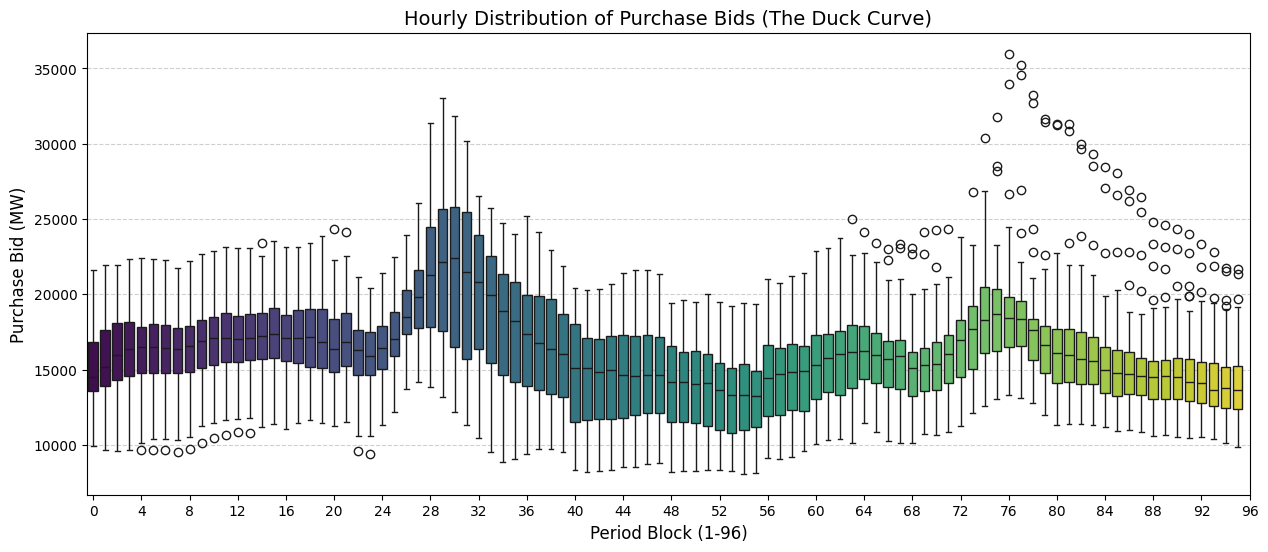

Average Bid on weekday and weekend:
day_type
Weekday    16427.944976
Weekend    14873.829830
Name: purchase_bid, dtype: float64


/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_50877/3151125472.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='weekday_enum', y=TARGET_COL, palette="viridis")


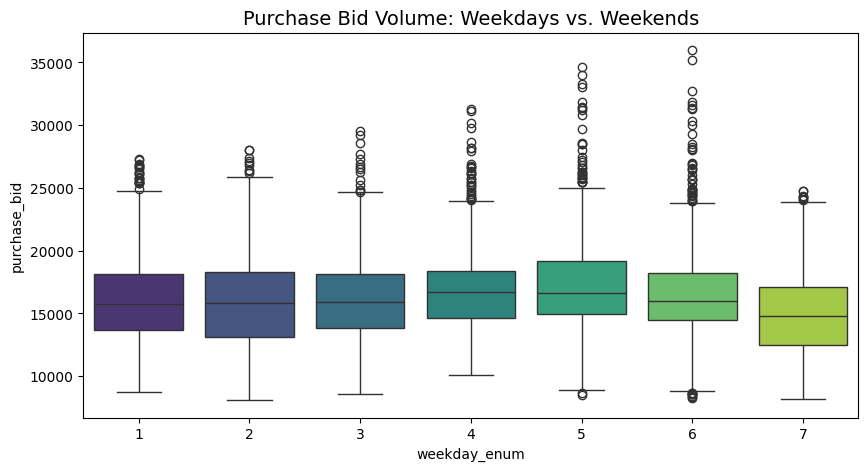

Average Bid on Holidays vs Working Days:
is_holiday
0    16288.061863
1    15140.761979
Name: purchase_bid, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data_temporal = data.copy()

# --- 1. Hourly Profiling (The Duck Curve) ---
def plot_hourly_distribution(df):
    plt.figure(figsize=(15, 6))
    # Boxplot shows the median, quartiles, and outliers for each 15-min block
    sns.boxplot(data=df, x='period_enum', y=TARGET_COL, palette="viridis")
    plt.title("Hourly Distribution of Purchase Bids (The Duck Curve)", fontsize=14)
    plt.xlabel("Period Block (1-96)", fontsize=12)
    plt.ylabel("Purchase Bid (MW)", fontsize=12)
    plt.xticks(range(0, 97, 4), labels=range(0, 97, 4)) # Show hours on X-axis
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# --- 2. Weekly Seasonality (Weekday vs Weekend) ---
def plot_weekly_impact(df):
    # Categorize into Weekday (1-5) and Weekend (6-7)
    df['day_type'] = df['weekday_enum'].apply(lambda x: 'Weekend' if x == 7 else 'Weekday')
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='weekday_enum', y=TARGET_COL, palette="viridis")
    # sns.violinplot(data=df, x='day_type', y='purchase_bid', split=True, inner="quart", palette="Pastel1")
    plt.title("Purchase Bid Volume: Weekdays vs. Weekends", fontsize=14)
    weekday_stats = df.groupby('day_type')[TARGET_COL].mean()
    print("Average Bid on weekday and weekend:")
    print(weekday_stats)
    plt.show()

# --- 3. Holiday Identification ---
def add_holiday_flags(df):
    # List of major Indian holidays for Feb - April 2026
    # Note: These dates affect industrial load significantly
    holidays_2026 = [
        '2026-02-18', # Maha Shivaratri
        '2026-03-03', # Holi
        '2026-03-19', # Gudi Padwa / Ugadi
        '2026-03-28', # Ram Navami
        '2026-04-03', # Good Friday
        '2026-04-10', # Ambedkar Jayanti
    ]
    
    df['is_holiday'] = df['period_start'].dt.strftime('%Y-%m-%d').isin(holidays_2026).astype(int)
    
    # Check impact
    holiday_stats = df.groupby('is_holiday')[TARGET_COL].mean()
    print("Average Bid on Holidays vs Working Days:")
    print(holiday_stats)
    return df

# Execution
data_temporal["period_enum"] = data_temporal["period_start"].dt.hour * 4 + data_temporal["period_start"].dt.minute // 15 + 1
data_temporal["weekday_enum"] = data_temporal["period_start"].dt.weekday + 1

plot_hourly_distribution(data_temporal)
plot_weekly_impact(data_temporal)
data_temporal = add_holiday_flags(data_temporal)

### Takeaways
1. Outliers present during evening hours from period 75 to 96 to 4, as a result, is_evening parameter is a good addition.
2. Significant difference between energy consumed on weekday over weekend.
3. Energy consumption during holiday is lower, so would be worthwhile to include is_holiday boolean.

## Distribution & Transformation Analysis

`data.describe()` gave us the central tendency. Before fitting SARIMA (which assumes Gaussian residuals) or scaling features for an LSTM, we check **shape**:

- Skewness and kurtosis per target.
- Histogram + KDE for visual asymmetry.
- Q-Q plot vs the normal distribution.
- Box-Cox optimal `λ` to suggest the variance-stabilizing transform — `λ ≈ 0` ⇒ use `log1p`, `λ ≈ 0.5` ⇒ use `sqrt`, `λ ≈ 1` ⇒ no transform needed.

Distribution moments per target:
                   mean   median        std   skew  kurtosis        iqr
purchase_bid  16405.953  15997.0   4169.599  1.822     8.582   4432.275
sell_bid      23704.252  20085.2  13786.758  0.663    -0.395  19972.400


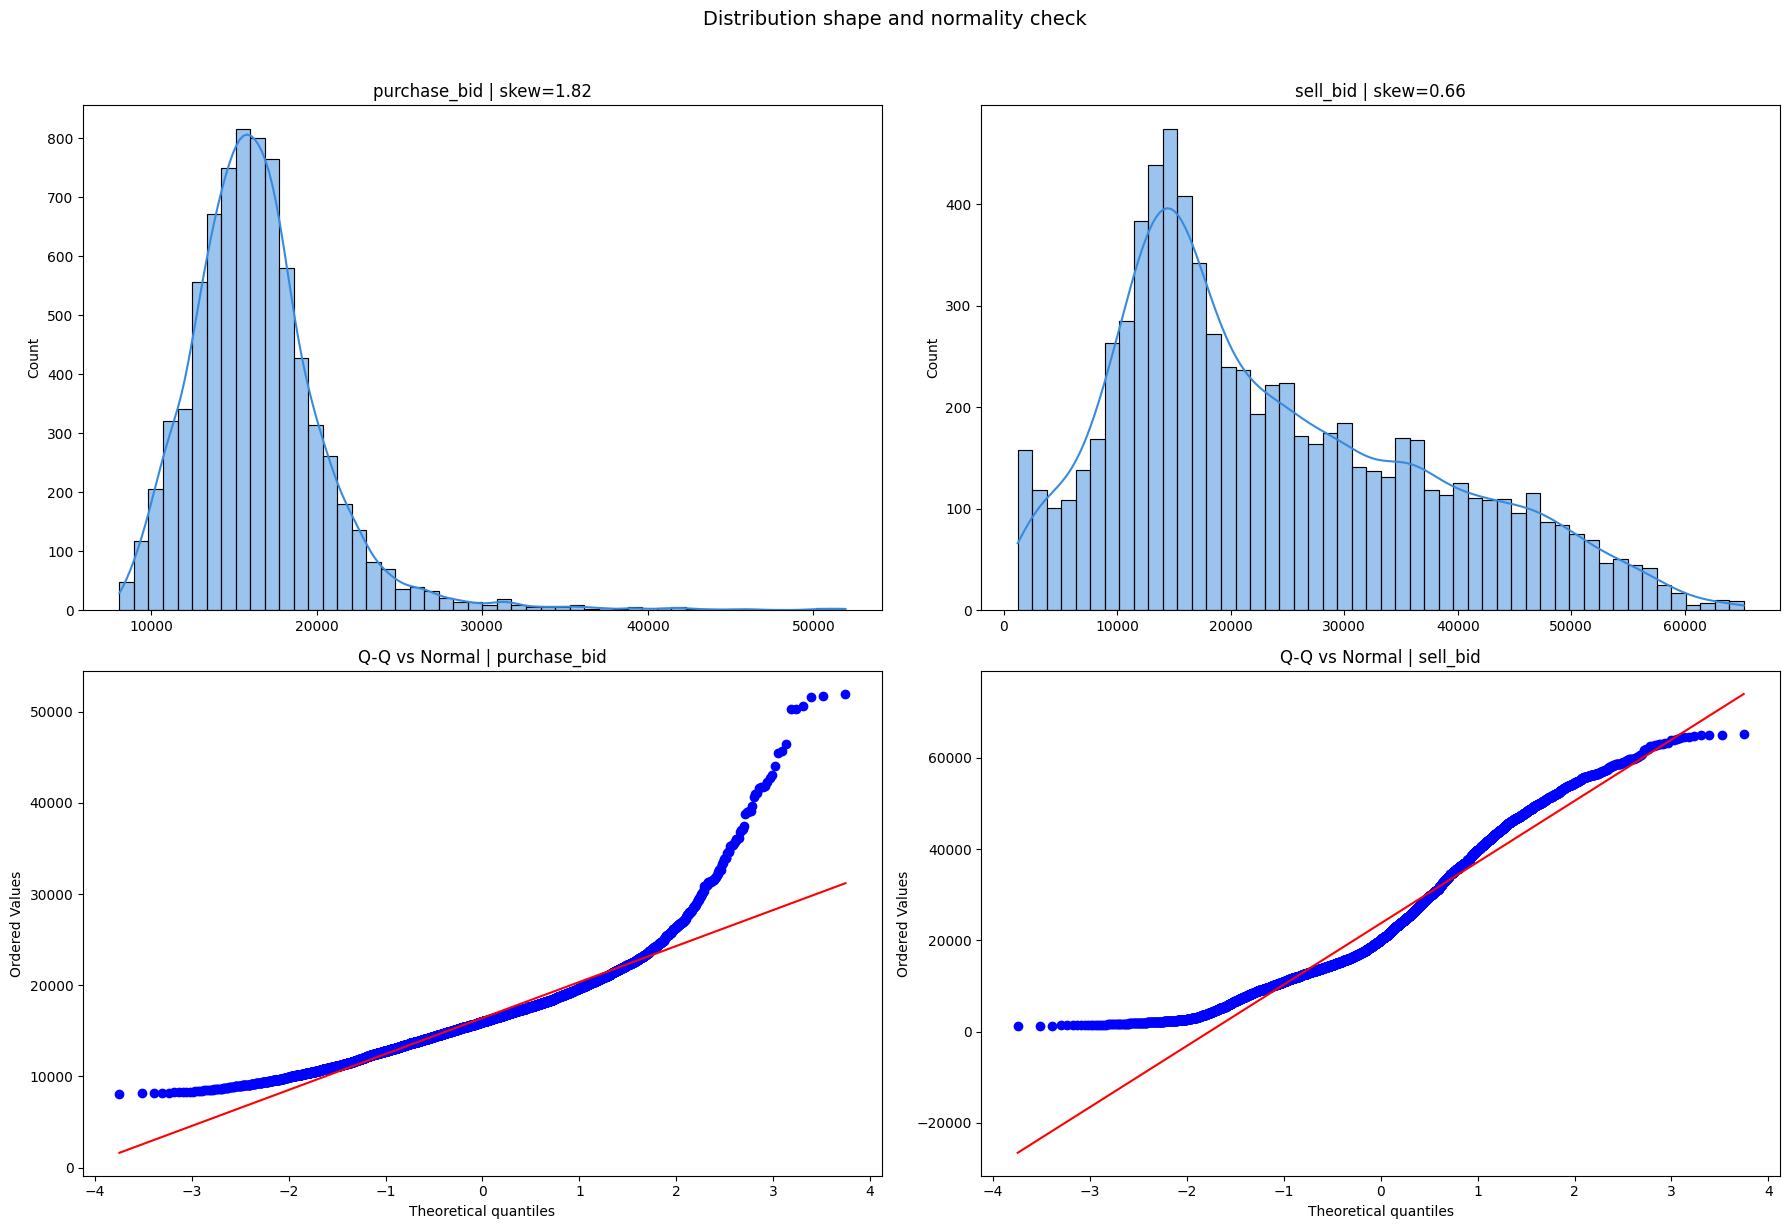


Box-Cox optimal lambda  (λ ≈ 0 ⇒ log,  λ ≈ 0.5 ⇒ sqrt,  λ ≈ 1 ⇒ no transform):
  purchase_bid   | λ*=-0.319 | raw skew=+1.82 | log1p skew=+0.32
  sell_bid       | λ*=+0.433 | raw skew=+0.66 | log1p skew=-0.92


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot, boxcox

DIST_TARGETS = ["purchase_bid", "sell_bid"]

moments = pd.DataFrame({
    "mean":     clean[DIST_TARGETS].mean(),
    "median":   clean[DIST_TARGETS].median(),
    "std":      clean[DIST_TARGETS].std(),
    "skew":     clean[DIST_TARGETS].skew(),
    "kurtosis": clean[DIST_TARGETS].kurt(),
    "iqr":      clean[DIST_TARGETS].quantile(0.75) - clean[DIST_TARGETS].quantile(0.25),
}).round(3)
print("Distribution moments per target:")
print(moments)

fig, axes = plt.subplots(2, len(DIST_TARGETS), figsize=(18, 12))
for col_idx, col in enumerate(DIST_TARGETS):
    sns.histplot(clean[col], kde=True, bins=50, ax=axes[0, col_idx], color="#378ADD")
    axes[0, col_idx].set_title(f"{col} | skew={clean[col].skew():.2f}")
    axes[0, col_idx].set_xlabel("")

    probplot(clean[col], dist="norm", plot=axes[1, col_idx])
    axes[1, col_idx].set_title(f"Q-Q vs Normal | {col}")

plt.suptitle("Distribution shape and normality check", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

print("\nBox-Cox optimal lambda  (λ ≈ 0 ⇒ log,  λ ≈ 0.5 ⇒ sqrt,  λ ≈ 1 ⇒ no transform):")
for col in DIST_TARGETS:
    s = clean[col]
    s_pos = s[s > 0]
    if s_pos.empty:
        print(f"  {col:14s} | skipped (no strictly positive values)")
        continue
    _, lam = boxcox(s_pos.values)
    skew_raw = s.skew()
    skew_log = np.log1p(s).skew()
    print(f"  {col:14s} | λ*={lam:+.3f} | raw skew={skew_raw:+.2f} | log1p skew={skew_log:+.2f}")

### Takeaway

- If `|skew| > 1` or the Q-Q tail bends sharply away from the diagonal, fit SARIMA on `log1p(target)` (more stable than raw Box-Cox at inference time because the inverse is just `expm1`).
- For LightGBM, skewed targets are best served by `objective="regression_l1"` (MAE, robust) or `objective="tweedie"` for strictly-positive volume targets — both perform better than default L2 on heavy-tailed data.
- For LSTM:
  - skew > 1 ⇒ apply `np.log1p` *before* scaling.
  - heavy-tailed kurtosis ⇒ use `RobustScaler` instead of `StandardScaler` so outliers don't compress the rest of the data into a narrow band.
- `mcp` will likely be the most non-normal because of its 10,000 ceiling; this is the column that benefits most from quantile / Tobit modeling rather than transformation.

## Lag Feature Scouting

Each of the three modeling tracks consumes "the past" differently:

- **SARIMA(p, d, q)(P, D, Q, m)** picks orders directly from ACF/PACF on the seasonally-differenced series - have done this analysis in the Time Series module.
- **LightGBM** needs an explicit lag menu (lag-1, lag-96, lag-672, plus rolling stats). We scout candidates with mutual information.
- **LSTM** needs an input-window length. We pick it from the lag where self-similarity drops off.

Below: mutual-information bar chart over candidate lag features, and a per-hour view of how lag-96 vs lag-672 self-similarity varies — important because some hours are far more autoregressive than others.

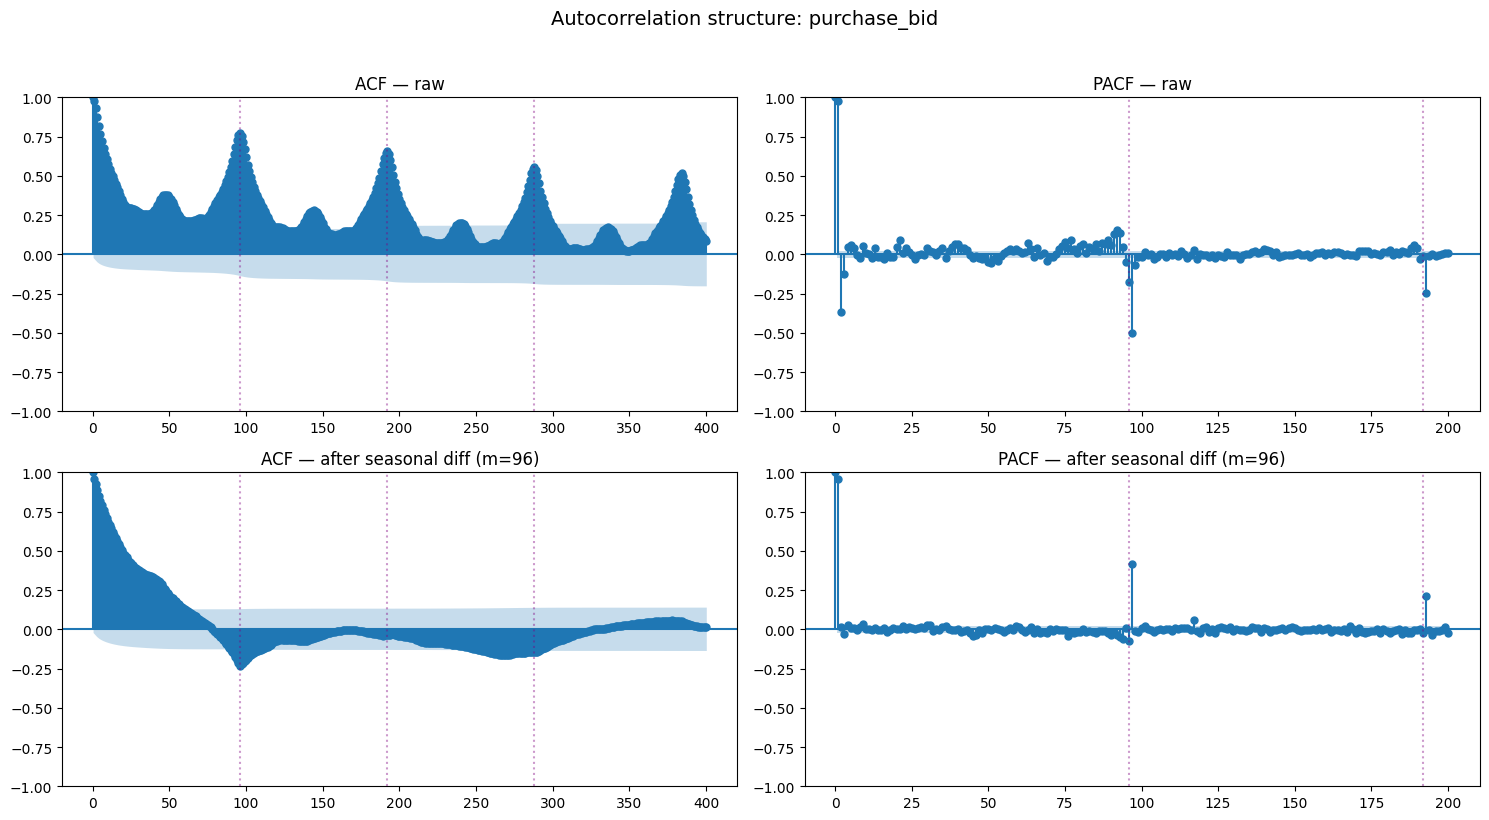

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.feature_selection import mutual_info_regression

LAG_TARGET = "purchase_bid"
series = data.set_index("period_start").asfreq("15min")[LAG_TARGET].dropna()

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
plot_acf(series, lags=400, ax=axes[0, 0]);  axes[0, 0].set_title("ACF — raw")
plot_pacf(series, lags=200, ax=axes[0, 1], method="ywm"); axes[0, 1].set_title("PACF — raw")

s_diff = series.diff(96).dropna()
plot_acf(s_diff, lags=400, ax=axes[1, 0]);  axes[1, 0].set_title("ACF — after seasonal diff (m=96)")
plot_pacf(s_diff, lags=200, ax=axes[1, 1], method="ywm"); axes[1, 1].set_title("PACF — after seasonal diff (m=96)")

for ax in axes.flat:
    for spike in (96, 192, 288, 672):
        if spike <= int(ax.get_xlim()[1]):
            ax.axvline(spike, color="purple", linestyle=":", alpha=0.4)
plt.suptitle(f"Autocorrelation structure: {LAG_TARGET}", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

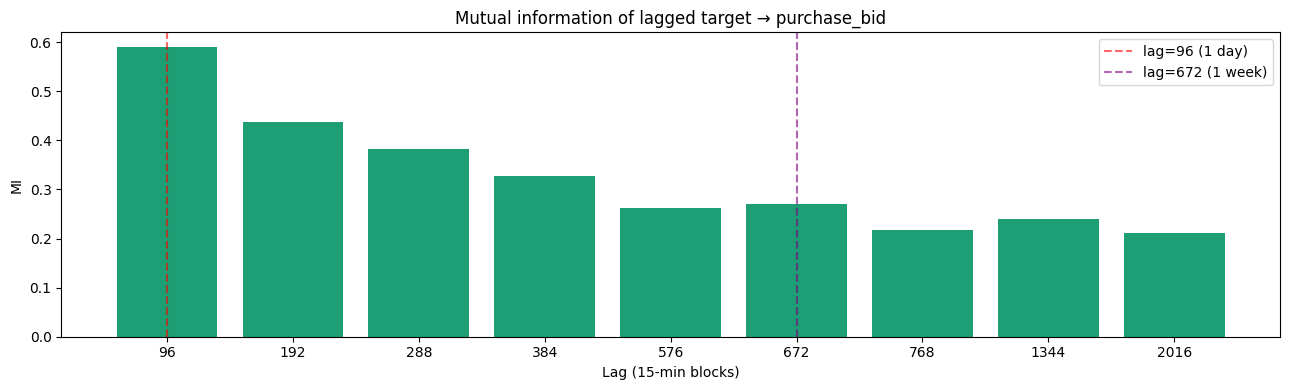

Top-5 lags by MI (use these in the LightGBM feature set):
96     0.5903
192    0.4365
288    0.3819
384    0.3282
672    0.2705
Name: MI, dtype: float64


/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_50877/4027886880.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


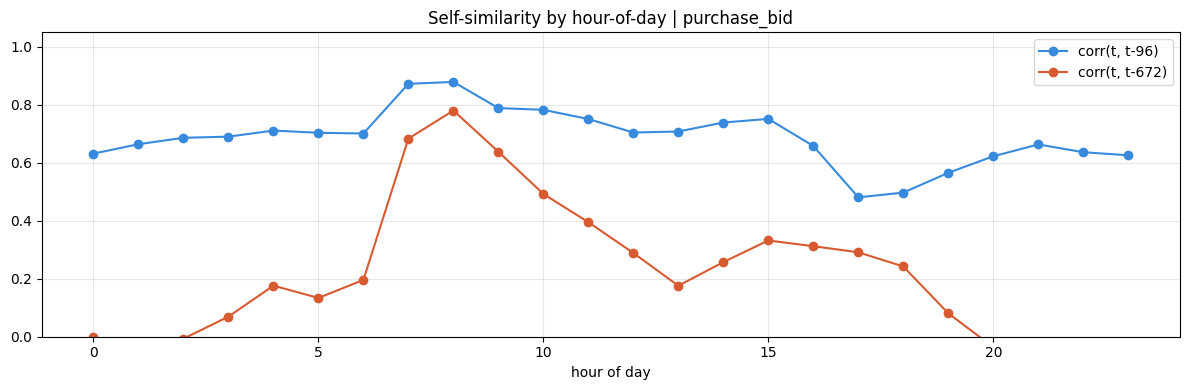

In [13]:
lag_grid = [96, 192, 288, 384, 576, 672, 768, 1344, 2016]
lag_frame = pd.concat({f"lag_{L}": series.shift(L) for L in lag_grid}, axis=1).dropna()
y_aligned = series.loc[lag_frame.index]
mi = mutual_info_regression(lag_frame.values, y_aligned.values, random_state=0)
mi_df = pd.Series(mi, index=lag_grid, name="MI")

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar([str(L) for L in lag_grid], mi_df.values, color="#1D9E75")
for spike, label, color in [(96, "1 day", "red"), (672, "1 week", "purple")]:
    ax.axvline(str(spike), color=color, linestyle="--", alpha=0.6, label=f"lag={spike} ({label})")
ax.set_title(f"Mutual information of lagged target → {LAG_TARGET}")
ax.set_xlabel("Lag (15-min blocks)"); ax.set_ylabel("MI")
ax.legend(); plt.tight_layout(); plt.show()

print("Top-5 lags by MI (use these in the LightGBM feature set):")
print(mi_df.sort_values(ascending=False).head(5).round(4))

hourly = data.copy()
hourly["hr"] = hourly["period_start"].dt.hour
hourly["lag_96"]  = hourly[LAG_TARGET].shift(96)
hourly["lag_672"] = hourly[LAG_TARGET].shift(672)
hourly = hourly.dropna(subset=["lag_96", "lag_672"])
hour_corr = (
    hourly.groupby("hr")
          .apply(lambda g: pd.Series({
              "corr(t, t-96)":  g[LAG_TARGET].corr(g["lag_96"]),
              "corr(t, t-672)": g[LAG_TARGET].corr(g["lag_672"]),
          }))
)
fig, ax = plt.subplots(figsize=(12, 4))
hour_corr.plot(ax=ax, marker="o", color=["#378ADD", "#D85A30"])
ax.set_title(f"Self-similarity by hour-of-day | {LAG_TARGET}")
ax.set_ylim(0, 1.05); ax.set_xlabel("hour of day")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Takeaway

- **LightGBM lag menu** (defensible from the MI bar chart): include the top-5 lags by MI plus rolling mean/std at windows {96, 672}. Persistence at lag-1 is usually highest in MI but is *not available* at a 7-day forecast horizon — exclude any lag < 672 from features used to forecast `t = origin + h ≥ 96`, otherwise you leak future information at inference.
- **LSTM input window**: choose the smallest window that captures the dominant lag spike. If MI peaks at 672, an input window of `2 × 672 = 1344` blocks (2 weeks) is a reasonable starting point; longer windows hurt training stability without much gain.
- The hour-of-day plot tells you which hours are most predictable. If `corr(t, t-672)` is high in the evening peak (18–22h) but low at 02–05h, consider hour-segmented models or quantile regression rather than a single global model.

## Volatility & Heteroscedasticity

A series can have a clean seasonal mean but a *changing* variance — typical of energy markets where evening peaks are noisier than off-peak. This affects three modeling decisions:

- **SARIMA**: if variance is non-constant, fit on `log` or `Box-Cox` series, not raw.
- **LightGBM**: a multiplicative-noise series is a candidate for `objective="tweedie"` or quantile regression.
- **LSTM**: scale on a *robust* statistic (median/IQR) rather than mean/std, and consider variance-stabilizing transforms before training.

We check three things: (1) rolling std overlay, (2) variance-vs-level scatter, and (3) Engle's ARCH test for volatility clustering on residual returns.

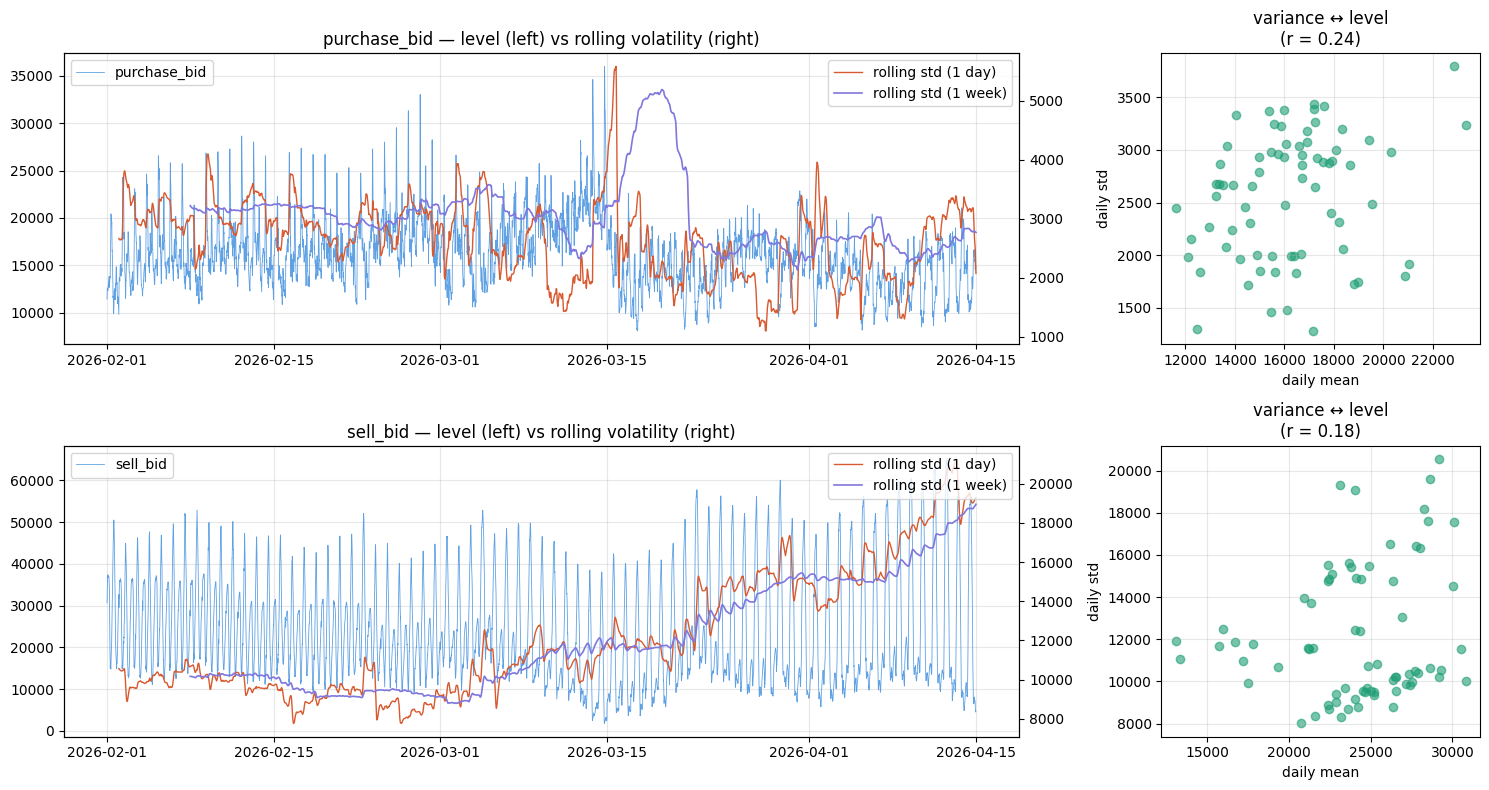


Engle ARCH test on first-differenced series (lags=96):
              ARCH_LM_stat  p_value  var_level_corr
target                                             
purchase_bid     2578.5626      0.0          0.2383
sell_bid         4455.3270      0.0          0.1801
  p < 0.05 ⇒ residual variance is autocorrelated (volatility clustering present).


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_arch

VOL_TARGETS = ["purchase_bid", "sell_bid"]
indexed = data.set_index("period_start").asfreq("15min")

fig, axes = plt.subplots(len(VOL_TARGETS), 2, figsize=(15, 4 * len(VOL_TARGETS)),
                         gridspec_kw={"width_ratios": [3, 1]})
arch_results = []

for row, target in enumerate(VOL_TARGETS):
    s = indexed[target].dropna()
    ax_ts, ax_sc = axes[row]

    ax_ts.plot(s.index, s.values, color="#378ADD", lw=0.6, alpha=0.8, label=target)
    ax_ts2 = ax_ts.twinx()
    ax_ts2.plot(s.rolling(96).std(),  color="#D85A30", lw=1.0, label="rolling std (1 day)")
    ax_ts2.plot(s.rolling(672).std(), color="#7F77DD", lw=1.2, label="rolling std (1 week)")
    ax_ts.set_title(f"{target} — level (left) vs rolling volatility (right)")
    ax_ts.legend(loc="upper left"); ax_ts2.legend(loc="upper right")
    ax_ts.grid(alpha=0.3)

    daily = s.groupby(s.index.date).agg(["mean", "std"]).dropna()
    ax_sc.scatter(daily["mean"], daily["std"], alpha=0.6, color="#1D9E75")
    ax_sc.set_xlabel("daily mean"); ax_sc.set_ylabel("daily std")
    ax_sc.set_title(f"variance ↔ level\n(r = {daily['mean'].corr(daily['std']):.2f})")
    ax_sc.grid(alpha=0.3)

    returns = s.diff().dropna()
    lm_stat, lm_p, _, _ = het_arch(returns, nlags=96)
    arch_results.append({"target": target, "ARCH_LM_stat": lm_stat, "p_value": lm_p,
                         "var_level_corr": daily["mean"].corr(daily["std"])})

plt.tight_layout(); plt.show()

print("\nEngle ARCH test on first-differenced series (lags=96):")
print(pd.DataFrame(arch_results).set_index("target").round(4))
print("  p < 0.05 ⇒ residual variance is autocorrelated (volatility clustering present).")

### Takeaway

- **Variance–level correlation > 0.5** is the threshold above which a `log1p` or Box-Cox transform pays off. If you see this, fit SARIMA on `log1p(target)` and undo the transform after forecasting.
- **ARCH p < 0.05** on first differences means residuals have volatility clustering. SARIMA point forecasts are still unbiased, but their **prediction intervals will be wrong** — combine SARIMA with a GARCH(1,1) on residuals if interval coverage matters.
- For LightGBM, multiplicative noise is a clean argument for **quantile regression** (`objective="quantile"` at α = 0.1, 0.5, 0.9) — quantiles natively respect non-constant variance and give you intervals "for free".
- For LSTM, replace `StandardScaler` with `RobustScaler` (or a `log1p` pre-transform) so that high-variance evening peaks don't dominate the gradient.

## Environmental features

In [17]:
import requests
import pandas as pd

df_temp = data.copy()

def get_nci_data(start_date, end_date):
    # Defining cities and their weights for the NCI
    # Mumbai (High Commercial), Delhi (High Residential/Peak), Akola (Heat Epicenter)
    locations = {
        "delhi": {"lat": 28.61, "lon": 77.20, "weight": 0.5},
        "mumbai": {"lat": 19.07, "lon": 72.88, "weight": 0.3},
        "akola": {"lat": 20.70, "lon": 77.01, "weight": 0.2}
    }
    
    all_weather = pd.DataFrame()

    for name, loc in locations.items():
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": loc["lat"],
            "longitude": loc["lon"],
            "start_date": start_date,
            "end_date": end_date,
            "daily": "temperature_2m_max",
            "timezone": "Asia/Kolkata"
        }
        res = requests.get(url, params=params).json()
        
        temp_df = pd.DataFrame({
            "date": pd.to_datetime(res["daily"]["time"]),
            f"temp_{name}": res["daily"]["temperature_2m_max"]
        })
        
        if all_weather.empty:
            all_weather = temp_df
        else:
            all_weather = all_weather.merge(temp_df, on="date")

    # Calculate the National Cooling Index (Weighted Average)
    all_weather['NCI'] = 0
    for name, loc in locations.items():
        all_weather['NCI'] += all_weather[f'temp_{name}'] * loc['weight']
    
    return all_weather

# 1. Fetch the multi-city data
weather_master = get_nci_data("2026-02-01", "2026-04-21")

# 2. Merge into your main dataframe
df_temp['date_only'] = df_temp['period_start'].dt.date
weather_master['date_only'] = weather_master['date'].dt.date

df_temp = df_temp.merge(weather_master[['date_only', 'NCI', 'temp_delhi', 'temp_akola', 'temp_mumbai']], on='date_only', how='left')

# 3. Create a non-linear 'Cooling Demand' feature
# This captures the 'spike' effect when NCI crosses 35 degrees
df_temp['cooling_load_factor'] = (df_temp['NCI'] - 30).clip(lower=0)**2

print("NCI and Cooling Load Factor added to data_clean.")

NCI and Cooling Load Factor added to data_clean.


In [39]:
weather_master.to_csv("../../data/weather/weather_master.csv", index=False)

,date,temp_delhi,temp_mumbai,temp_akola,NCI,date_only
0,2026-02-01,20.8,31.8,30.4,26.02,2026-02-01
1,2026-02-02,19.7,33.2,31.3,26.07,2026-02-02
2,2026-02-03,19.6,32.2,30.8,25.62,2026-02-03
3,2026-02-04,20.2,33.8,30.4,26.32,2026-02-04
4,2026-02-05,21.2,33.8,30.5,26.84,2026-02-05
...,...,...,...,...,...,...
75,2026-04-17,40.2,32.5,41.3,38.11,2026-04-17
76,2026-04-18,40.2,34.2,40.8,38.52,2026-04-18
77,2026-04-19,40.1,34.2,41.3,38.57,2026-04-19
78,2026-04-20,39.5,35.0,40.5,38.35,2026-04-20


In [18]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# 2. Add Purchase Bid (Primary Axis)
fig.add_trace(
    go.Scatter(
        x=df_temp['period_start'], 
        y=df_temp['purchase_bid'], 
        name="Purchase Bid (MW)",
        line=dict(color="#378ADD", width=1.5),
        opacity=0.8
    ),
    secondary_y=False,
)

# 3. Add Max Temperature (Secondary Axis)
# Note: This will appear as a 'staircase' because it is daily data
fig.add_trace(
    go.Scatter(
        x=df_temp['period_start'], 
        y=df_temp['cooling_load_factor'], 
        name="Max Temp (°C)",
        line=dict(color="#FF4B4B", width=3, dash='dot'),
    ),
    secondary_y=True,
)

# 4. Add layout details
fig.update_layout(
    title_text="<b>Impact of Heatwaves on IEX Purchase Bids (Feb - Apr 2026)</b>",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Set y-axes titles
fig.update_yaxes(title_text="<b>Purchase Bid</b> (MW)", secondary_y=False)
fig.update_yaxes(title_text="<b>cooling_load_factore</b> (°C)", secondary_y=True)

fig.show()

In [19]:
# Filter for heatwave periods to see the 'true' driver
heatwave_data = df_temp[df_temp['NCI'] > 34]

# Check correlation of individual cities against purchase_bid
city_cols = [col for col in df_temp.columns if 'temp_' in col]
correlations = heatwave_data[city_cols + ['purchase_bid']].corr()['purchase_bid'].sort_values(ascending=False)

print("Correlation with Purchase Bids during Heatwaves:")
print(correlations)

Correlation with Purchase Bids during Heatwaves:
purchase_bid    1.000000
temp_mumbai     0.215529
temp_delhi     -0.119707
temp_akola     -0.211647
Name: purchase_bid, dtype: float64


In [20]:
# Check if yesterday's temperature in a city predicts today's bids better
for city in city_cols:
    corr_today = df_temp['purchase_bid'].corr(df_temp[city])
    corr_lagged = df_temp['purchase_bid'].corr(df_temp[city].shift(96)) # 96 blocks = 1 day
    print(f"{city} -> Today: {corr_today:.2f}, Lagged (Yesterday): {corr_lagged:.2f}")

temp_delhi -> Today: 0.14, Lagged (Yesterday): 0.15
temp_akola -> Today: 0.03, Lagged (Yesterday): 0.05
temp_mumbai -> Today: 0.15, Lagged (Yesterday): 0.21


In [21]:
import plotly.express as px

# Prepare data for a heatmap
temp_only = df_temp[city_cols + ['date_only']].drop_duplicates().set_index('date_only')

fig = px.imshow(temp_only.T, 
                labels=dict(x="Date", y="City", color="Temp (°C)"),
                title="Regional Temperature Heatmap vs. IEX Spikes",
                color_continuous_scale="Reds")
fig.show()

## Cross-correlation with Weather (Multi-lag CCF)

The earlier blocks computed a single same-day correlation between NCI and bids, then a 1-day lagged comparison per city. To pick weather as an exogenous variable for **SARIMAX** and **LightGBM**, we need three more pieces of evidence:

1. **Direction of causality**: does today's NCI predict tomorrow's bids, or do bids precede temperature swings? CCF over ±10 days makes this visible.
2. **Regime conditioning**: weather correlation is near-zero in February and strong in April. Compute the correlation per month rather than collapsing all data into one number.
3. **Peak vs mean response**: heat affects the *evening peak* far more than the daily mean. Compare both targets explicitly.

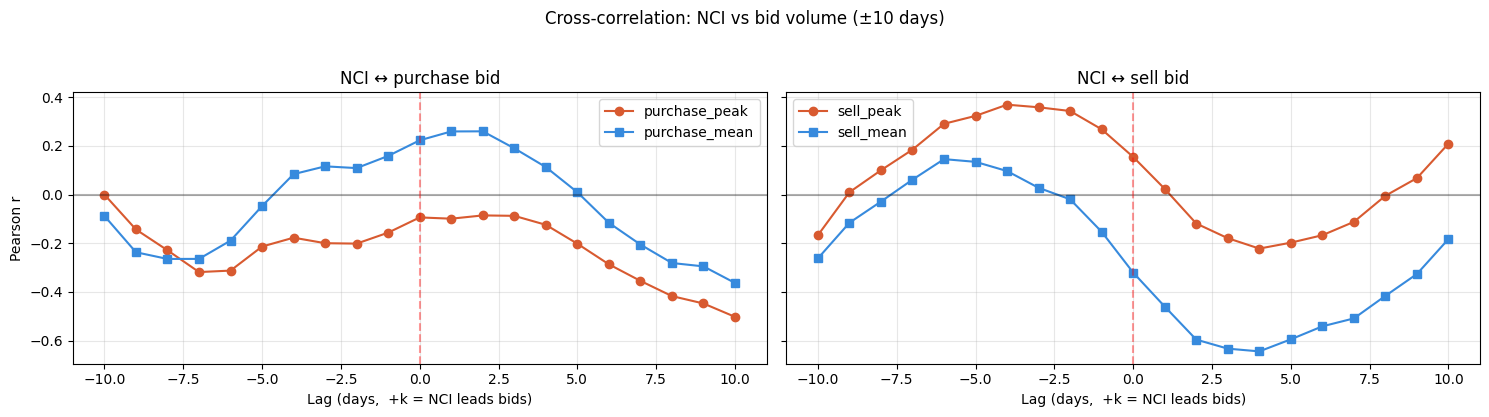

Per-month correlation (regime conditioning):
         n_days  corr(NCI, purchase_peak)  corr(NCI, purchase_mean)  \
month                                                                 
2026-02    28.0                     0.500                     0.500   
2026-03    31.0                     0.480                     0.595   
2026-04    14.0                     0.349                     0.469   

         corr(NCI, sell_peak)  
month                          
2026-02                -0.355  
2026-03                 0.045  
2026-04                 0.079  

Heatwave threshold (NCI p75) = 34.1
                purchase_mean         purchase_peak         sell_mean        
                         mean     std          mean     std      mean     std
regime                                                                       
hot (NCI ≥ p75)       17648.5  2917.1       23519.9  5093.6   23024.1  4820.0
mild                  15681.9  2007.1       23020.4  4354.0   24591.7  3569.2


/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_50877/4225914875.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

daily = (
    df_temp.groupby("date_only")
           .agg(purchase_mean=("purchase_bid", "mean"),
                purchase_peak=("purchase_bid", "max"),
                sell_mean=("sell_bid", "mean"),
                sell_peak=("sell_bid", "max"),
                NCI=("NCI", "first"))
           .reset_index()
           .sort_values("date_only")
           .reset_index(drop=True)
)
daily["month"] = pd.to_datetime(daily["date_only"]).dt.to_period("M").astype(str)


def signed_ccf(x: pd.Series, y: pd.Series, max_lag: int = 10) -> pd.Series:
    lags = np.arange(-max_lag, max_lag + 1)
    out = []
    for L in lags:
        xs = x.shift(L)
        mask = xs.notna() & y.notna()
        out.append(np.corrcoef(xs[mask], y[mask])[0, 1] if mask.sum() > 5 else np.nan)
    return pd.Series(out, index=lags, name="ccf")


fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for ax, side in zip(axes, ["purchase", "sell"]):
    ccf_peak = signed_ccf(daily["NCI"], daily[f"{side}_peak"], max_lag=10)
    ccf_mean = signed_ccf(daily["NCI"], daily[f"{side}_mean"], max_lag=10)
    ccf_peak.plot(ax=ax, marker="o", label=f"{side}_peak", color="#D85A30")
    ccf_mean.plot(ax=ax, marker="s", label=f"{side}_mean", color="#378ADD")
    ax.axhline(0, color="black", alpha=0.3)
    ax.axvline(0, color="red", linestyle="--", alpha=0.4)
    ax.set_xlabel("Lag (days,  +k = NCI leads bids)")
    ax.set_ylabel("Pearson r")
    ax.set_title(f"NCI ↔ {side} bid")
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Cross-correlation: NCI vs bid volume (±10 days)", y=1.03)
plt.tight_layout(); plt.show()

month_corr = (
    daily.groupby("month")
         .apply(lambda g: pd.Series({
             "n_days": len(g),
             "corr(NCI, purchase_peak)": g["NCI"].corr(g["purchase_peak"]),
             "corr(NCI, purchase_mean)": g["NCI"].corr(g["purchase_mean"]),
             "corr(NCI, sell_peak)":     g["NCI"].corr(g["sell_peak"]),
         }))
         .round(3)
)
print("Per-month correlation (regime conditioning):")
print(month_corr)

heat_thr = daily["NCI"].quantile(0.75)
hot_vs_mild = (
    daily.assign(regime=np.where(daily["NCI"] >= heat_thr, "hot (NCI ≥ p75)", "mild"))
         .groupby("regime")[["purchase_mean", "purchase_peak", "sell_mean"]]
         .agg(["mean", "std"])
         .round(1)
)
print(f"\nHeatwave threshold (NCI p75) = {heat_thr:.1f}")
print(hot_vs_mild)

### Takeaway

- Use the CCF plot to read the optimal **NCI lag** (the x-position of peak correlation). If the peak is at lag = 0–1, raw `NCI_t` and `NCI_{t-1}` are fine SARIMAX exogenous candidates; if it shifts to lag ≥ 2, also include a `NCI_{t-2}` feature.
- The per-month table tells you whether weather signal exists in February at all. If `corr(NCI, purchase_peak)` is near zero in Feb but ≥ 0.5 in April, do **not** train a single all-history regression on raw NCI — instead pass NCI as a *non-linear* feature (`(NCI - 30)_+²`, already engineered) so its effect can be ignored at low temperatures.
- A real 7-day-ahead pipeline must consume **forecasted** weather from Open-Meteo's forecast endpoint (`/forecast` rather than `/archive`), and the `weather_master` ingestion needs a backtest mode that uses *T-day-ahead forecasts* available at forecast origin.

## Forecastability & Naive Baselines

Before training SARIMA, LightGBM, or LSTM, we need a **floor**: the score that any sophisticated model must beat. We hold out the last 7 days (672 blocks) as the operational test horizon and evaluate four naive baselines:

1. `t-96` — yesterday's same 15-min block.
2. `t-672` — last week's same 15-min block (typically the strongest naive at this horizon).
3. **Mean of the last 4 days @ block** — smoothed seasonal naive.
4. **Weekday × block mean** — average of every observed `(weekday, block)` pair from training.

If a fitted model cannot beat `t-672` on MAE, the model is broken or the features are mis-specified.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forecasting.evaluation.metrics import regression_metrics

HORIZON = 7 * 96
PERIOD = 96

df_eval = data.set_index("period_start").asfreq("15min")
train, test = df_eval.iloc[:-HORIZON], df_eval.iloc[-HORIZON:]
print(f"Train : {train.index.min()} → {train.index.max()}  ({len(train):,} rows)")
print(f"Test  : {test.index.min()} → {test.index.max()}   ({len(test):,} rows)")


def naive_repeat_lag(train_series: pd.Series, horizon: int, lag: int) -> np.ndarray:
    base = train_series.iloc[-lag:].values
    return np.tile(base, int(np.ceil(horizon / lag)))[:horizon]


def naive_mean_last_k_days(train_series: pd.Series, horizon: int, k: int = 4) -> np.ndarray:
    tail = train_series.iloc[-k * PERIOD :].values.reshape(k, PERIOD)
    base = np.nanmean(tail, axis=0)
    return np.tile(base, int(np.ceil(horizon / PERIOD)))[:horizon]


def naive_weekday_block_mean(train_series: pd.Series, test_index: pd.DatetimeIndex) -> np.ndarray:
    frame = pd.DataFrame({"y": train_series.dropna()})
    frame["wd"] = frame.index.weekday
    frame["pe"] = frame.index.hour * 4 + frame.index.minute // 15
    table = frame.groupby(["wd", "pe"])["y"].mean()
    return np.array(
        [table.loc[(t.weekday(), t.hour * 4 + t.minute // 15)] for t in test_index]
    )

targets = ["purchase_bid", "sell_bid"]
records, all_preds = [], {}

for target in targets:
    y_true = test[target].values
    train_series = train[target].dropna()

    preds = {
        "Persist t-96 (yesterday)":   naive_repeat_lag(train_series, HORIZON, 96),
        "Persist t-672 (last week)":  naive_repeat_lag(train_series, HORIZON, 672),
        "Mean of last 4 days":        naive_mean_last_k_days(train_series, HORIZON, k=4),
        "Weekday × block mean":       naive_weekday_block_mean(train_series, test.index),
    }
    all_preds[target] = preds

    for name, yhat in preds.items():
        m = regression_metrics(pd.Series(y_true), pd.Series(yhat))
        records.append({
            "target": target, "baseline": name,
            "MAE": m["mae"], "RMSE": m["rmse"],
            "mape_pct": m["mape"]*100, "r2": m["r2"],
        })

baselines_df = (
    pd.DataFrame(records)
      .set_index(["target", "baseline"])
      .round(2)
      .sort_index()
)
print("\nNaive baseline scores on the held-out 7-day window:")
baselines_df

Train : 2026-02-01 00:00:00 → 2026-04-07 23:45:00  (6,336 rows)
Test  : 2026-04-08 00:00:00 → 2026-04-14 23:45:00   (672 rows)

Naive baseline scores on the held-out 7-day window:


MAE      RMSE  mape_pct    r2
target       baseline                                                    
purchase_bid Mean of last 4 days        1511.59   2075.93     10.20  0.44
             Persist t-672 (last week)  2048.94   2522.19     14.92  0.17
             Persist t-96 (yesterday)   2221.57   2956.35     14.76 -0.14
             Weekday × block mean       3274.44   3993.82     26.68 -1.08
sell_bid     Mean of last 4 days        3612.09   4560.26     18.48  0.94
             Persist t-672 (last week)  5591.78   6995.80     26.69  0.86
             Persist t-96 (yesterday)   3016.40   3922.74     19.66  0.96
             Weekday × block mean       8858.48  11139.03     40.98  0.65

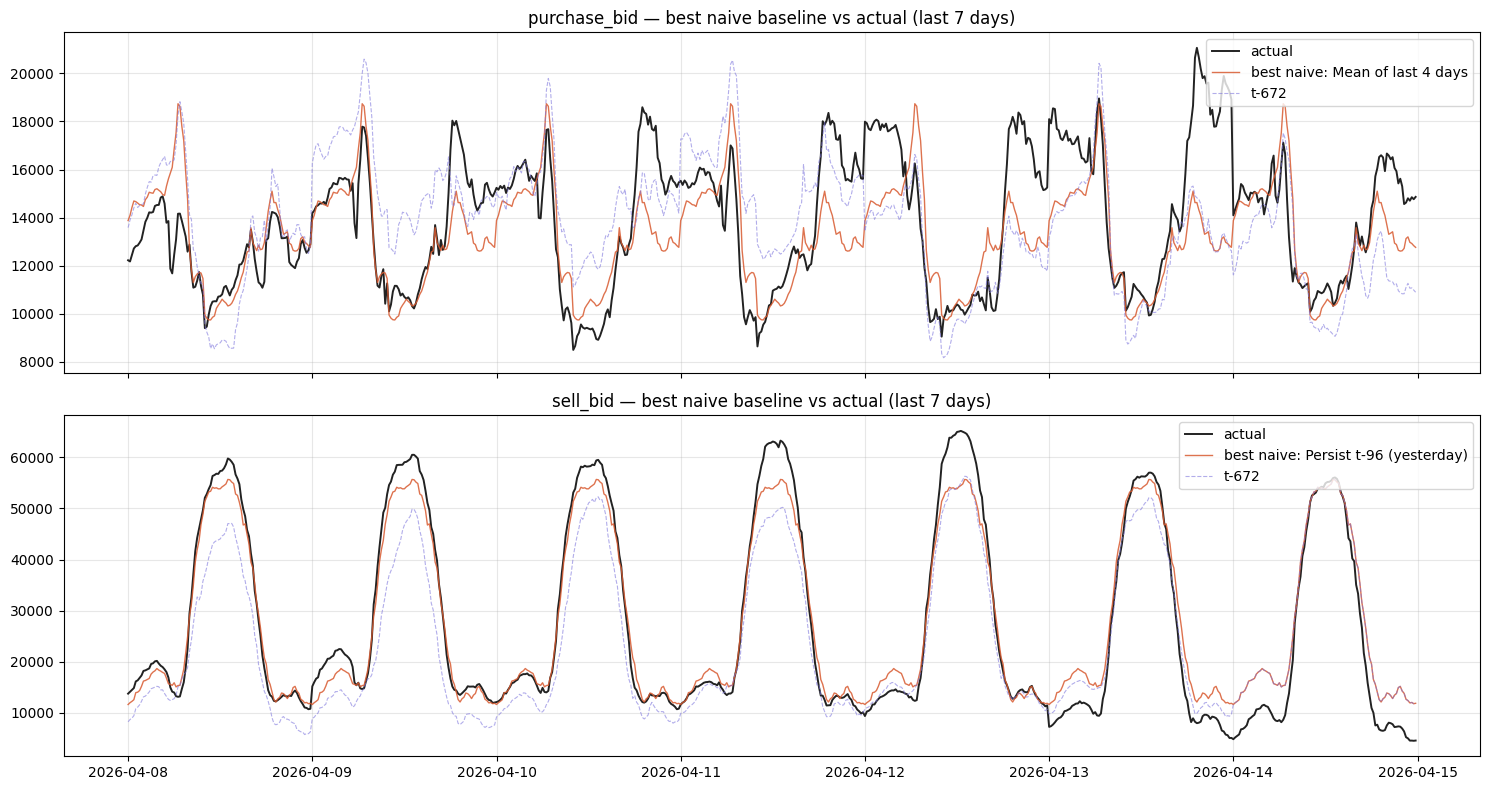


Best naive baseline per target (this is the bar to beat):
                              baseline      MAE     RMSE  MAPE_%  sMAPE_%
target                                                                   
purchase_bid       Mean of last 4 days  1511.59  2075.93   10.20    10.55
sell_bid      Persist t-96 (yesterday)  3016.40  3922.74   19.66    15.86


In [24]:
fig, axes = plt.subplots(len(targets), 1, figsize=(15, 4 * len(targets)), sharex=True)
if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    best_name = baselines_df.loc[target]["MAE"].idxmin()
    ax.plot(test.index, test[target].values, label="actual", color="#222", lw=1.4)
    ax.plot(test.index, all_preds[target][best_name], label=f"best naive: {best_name}",
            color="#D85A30", lw=1.0, alpha=0.85)
    ax.plot(test.index, all_preds[target]["Persist t-672 (last week)"],
            label="t-672", color="#7F77DD", lw=0.8, alpha=0.6, linestyle="--")
    ax.set_title(f"{target} — best naive baseline vs actual (last 7 days)")
    ax.legend(loc="upper right"); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

best_per_target = (
    baselines_df.reset_index()
                .loc[lambda d: d.groupby("target")["MAE"].idxmin()]
                .set_index("target")[["baseline", "MAE", "RMSE", "MAPE_%", "sMAPE_%"]]
)
print("\nBest naive baseline per target (this is the bar to beat):")
print(best_per_target)

### Takeaway

- The naive baseline scores above set the **acceptance threshold** for SARIMA / LightGBM / LSTM. Any final model with worse MAE/RMSE on the same 7-day holdout is not adding value.
- If `Persist t-672` (last-week-same-block) is strongest, weekly seasonality dominates and feature engineering must include lag-672 plus weekday × block interactions.
- If `Weekday × block mean` is strongest, the series is highly *deterministic-by-calendar* and a small LightGBM with calendar features will likely beat heavy SARIMA.
- Re-use this `train` / `test` split (last 7 days as holdout) consistently across all three modeling notebooks for an apples-to-apples benchmark.